# Dataset EDA for ABSA Project
This notebook performs EDA for the datasets used in the repository:
- FINAL_CLEANED_CORRECTED_SHUFFLED_DATASET_NO_DUPLICATE.jsonl
- NAVER_DATASET.jsonl

It works both locally and on Kaggle.

In [22]:
import os
import glob
import json
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')

In [23]:
# Local-first path resolution (works when running notebook from repo root or kaggle/ folder)
CWD = os.getcwd()
print('Current working directory:', CWD)

LOCAL_DATA_DIR_CANDIDATES = [
    os.path.join(CWD, 'Datasets'),
    os.path.join(CWD, '..', 'Datasets'),
]

def resolve_dataset_path(filename: str) -> str:
    # 1) Prefer local paths
    for base_dir in LOCAL_DATA_DIR_CANDIDATES:
        candidate = os.path.abspath(os.path.join(base_dir, filename))
        if os.path.exists(candidate):
            return candidate

    # 2) Fallback for Kaggle
    kaggle_candidates = glob.glob(f'/kaggle/input/*/{filename}')
    if kaggle_candidates:
        return kaggle_candidates[0]

    searched_dirs = [os.path.abspath(p) for p in LOCAL_DATA_DIR_CANDIDATES]
    raise FileNotFoundError(
        f'Cannot find {filename}. Checked local dirs: {searched_dirs} and /kaggle/input/*/'
    )

MAIN_DATASET_NAME = 'FINAL_CLEANED_CORRECTED_SHUFFLED_DATASET_NO_DUPLICATE.jsonl'
NAVER_DATASET_NAME = 'NAVER_DATASET.jsonl'

main_path = resolve_dataset_path(MAIN_DATASET_NAME)
naver_path = resolve_dataset_path(NAVER_DATASET_NAME)

print('Main dataset path :', main_path)
print('Naver dataset path:', naver_path)

Current working directory: /home/haiyan/xai-transformer/kaggle
Main dataset path : /home/haiyan/xai-transformer/Datasets/FINAL_CLEANED_CORRECTED_SHUFFLED_DATASET_NO_DUPLICATE.jsonl
Naver dataset path: /home/haiyan/xai-transformer/Datasets/NAVER_DATASET.jsonl


In [24]:
def load_jsonl_absa(path: str, dataset_name: str) -> pd.DataFrame:
    rows = []
    with open(path, 'r', encoding='utf-8') as f:
        for idx, line in enumerate(f):
            line = line.strip()
            if not line:
                continue
            rec = json.loads(line)

            text = rec.get('text', '')
            labels = rec.get('labels', [])

            if not labels:
                rows.append({
                    'dataset': dataset_name,
                    'record_id': idx,
                    'text': text,
                    'aspect': None,
                    'polarity': None
                })
                continue

            for lab in labels:
                rows.append({
                    'dataset': dataset_name,
                    'record_id': idx,
                    'text': text,
                    'aspect': lab.get('aspect'),
                    'polarity': str(lab.get('polarity', '')).lower().strip()
                })

    return pd.DataFrame(rows)

df_main = load_jsonl_absa(main_path, 'MAMA_SEMEVAL')
df_naver = load_jsonl_absa(naver_path, 'NAVER')
df_all = pd.concat([df_main, df_naver], ignore_index=True)

print('Main rows :', len(df_main))
print('Naver rows:', len(df_naver))
print('All rows  :', len(df_all))

Main rows : 30813
Naver rows: 881
All rows  : 31694


In [25]:
# Quick schema and samples
display(df_all.head(10))
display(df_all.info())

,dataset,record_id,text,aspect,polarity
0,MAMA_SEMEVAL,0,"the menu looked great, but the food was the bi...",menu,positive
1,MAMA_SEMEVAL,0,"the menu looked great, but the food was the bi...",food,negative
2,MAMA_SEMEVAL,1,Pros : - Great sound for a $ 100 speaker at mi...,sound,positive
3,MAMA_SEMEVAL,2,"Service was friendly, but not terribly attenti...",Service,positive
4,MAMA_SEMEVAL,2,"Service was friendly, but not terribly attenti...",dinner,neutral
5,MAMA_SEMEVAL,2,"Service was friendly, but not terribly attenti...",plates,neutral
6,MAMA_SEMEVAL,3,"Gobo's scallion pancakes are a bit dry, and th...",scallion pancakes,negative
7,MAMA_SEMEVAL,3,"Gobo's scallion pancakes are a bit dry, and th...",beet salad,negative
8,MAMA_SEMEVAL,3,"Gobo's scallion pancakes are a bit dry, and th...",beet s,negative
9,MAMA_SEMEVAL,3,"Gobo's scallion pancakes are a bit dry, and th...",majority,neutral


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31694 entries, 0 to 31693
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   dataset    31694 non-null  object
 1   record_id  31694 non-null  int64 
 2   text       31694 non-null  object
 3   aspect     31694 non-null  object
 4   polarity   31694 non-null  object
dtypes: int64(1), object(4)
memory usage: 1.2+ MB


None

In [26]:
def dataset_summary(df: pd.DataFrame, name: str) -> pd.Series:
    texts = df[['record_id', 'text']].drop_duplicates()
    labels_only = df[df['aspect'].notna()].copy()

    return pd.Series({
        'dataset': name,
        'num_records': texts['record_id'].nunique(),
        'num_text_rows': len(texts),
        'num_labeled_pairs': len(labels_only),
        'num_unique_aspects': labels_only['aspect'].nunique(),
        'avg_labels_per_record': labels_only.groupby('record_id').size().mean()
    })

summary_table = pd.DataFrame([
    dataset_summary(df_main, 'main'),
    dataset_summary(df_naver, 'naver')
])

summary_table

,dataset,num_records,num_text_rows,num_labeled_pairs,num_unique_aspects,avg_labels_per_record
0,main,16127,16127,30813,7514,1.910647
1,naver,642,642,881,606,1.372274


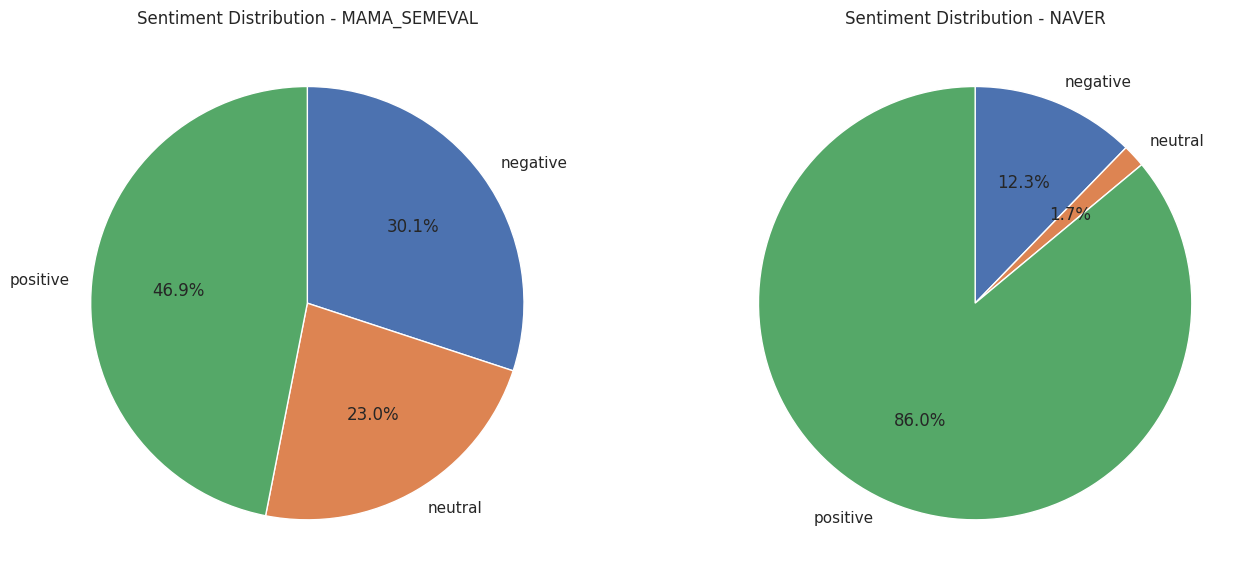

,dataset,polarity,count
0,MAMA_SEMEVAL,negative,9261
1,MAMA_SEMEVAL,neutral,7097
2,MAMA_SEMEVAL,positive,14455
3,NAVER,negative,108
4,NAVER,neutral,15
5,NAVER,positive,758


In [ ]:
# Sentiment distribution by dataset (pie charts)
plot_df = df_all[df_all['polarity'].notna()].copy()
sentiment_counts = (
    plot_df
    .groupby(['dataset', 'polarity'])
    .size()
    .reset_index(name='count')
)

# Keep a stable sentiment order for consistent colors/legend
sentiment_order = ['negative', 'neutral', 'positive']
pie_df = (
    sentiment_counts
    .pivot(index='dataset', columns='polarity', values='count')
    .reindex(columns=sentiment_order)
    .fillna(0)
)
datasets = pie_df.index.tolist()

fig, axes = plt.subplots(1, len(datasets), figsize=(7 * len(datasets), 6))
if len(datasets) == 1:
    axes = [axes]

legend_handles = None
legend_labels = [s.upper() for s in sentiment_order]

for ax, ds in zip(axes, datasets):
    values = pie_df.loc[ds].values.astype(int)

    def autopct_with_count(pct):
        total = values.sum()
        count = int(round(pct * total / 100.0))
        return f'{pct:.1f}% ({count})'

    wedges, texts, autotexts = ax.pie(
        values,
        labels=None,
        autopct=autopct_with_count,
        startangle=90,
        counterclock=False,
        wedgeprops={'edgecolor': 'white', 'linewidth': 1}
    )
    ax.set_title(f'Sentiment Distribution - {ds}')

    if legend_handles is None:
        legend_handles = wedges

# Put a shared legend at the top of the figure
fig.legend(
    legend_handles,
    legend_labels,
    loc='upper center',
    ncol=3,
    frameon=False,
    bbox_to_anchor=(0.5, 1.02)
)

plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()

sentiment_counts

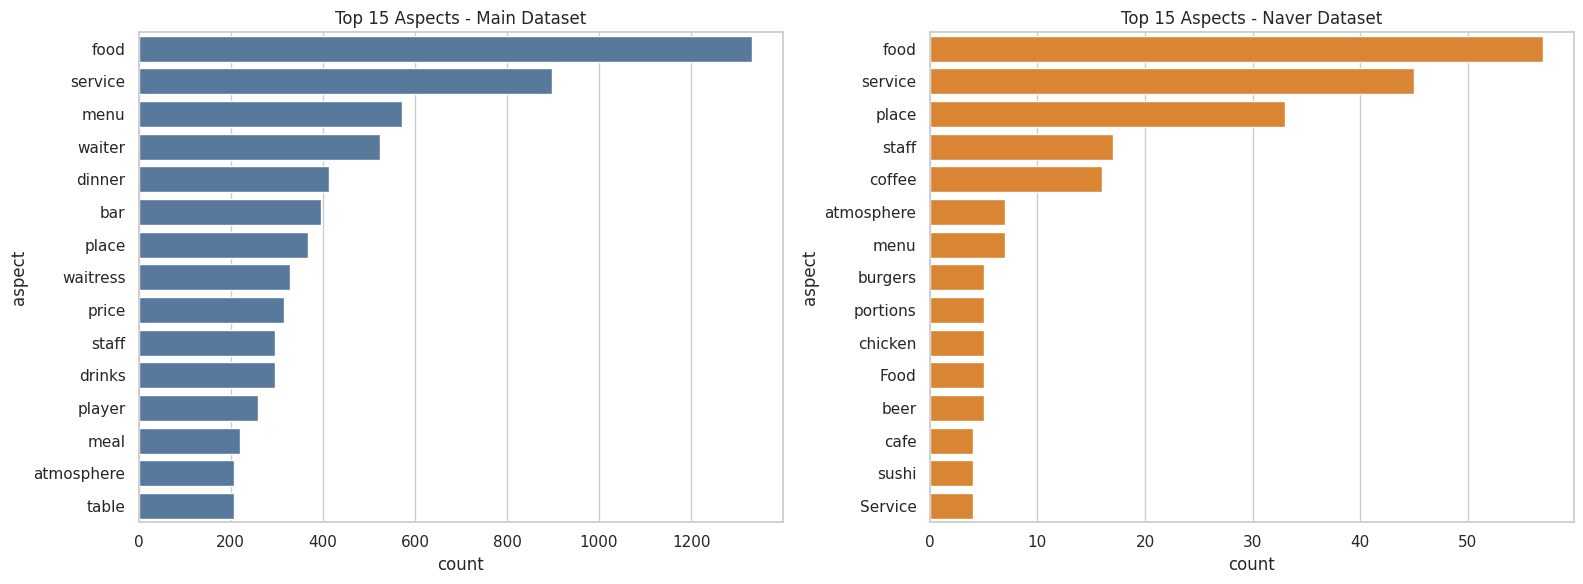

In [28]:
# Top aspects per dataset
def top_aspects(df: pd.DataFrame, top_n: int = 20) -> pd.DataFrame:
    tmp = df[df['aspect'].notna()].copy()
    return tmp['aspect'].value_counts().head(top_n).rename_axis('aspect').reset_index(name='count')

top_n = 15
top_main = top_aspects(df_main, top_n=top_n)
top_naver = top_aspects(df_naver, top_n=top_n)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.barplot(data=top_main, y='aspect', x='count', ax=axes[0], color='#4C78A8')
axes[0].set_title(f'Top {top_n} Aspects - Main Dataset')

sns.barplot(data=top_naver, y='aspect', x='count', ax=axes[1], color='#F58518')
axes[1].set_title(f'Top {top_n} Aspects - Naver Dataset')

plt.tight_layout()
plt.show()

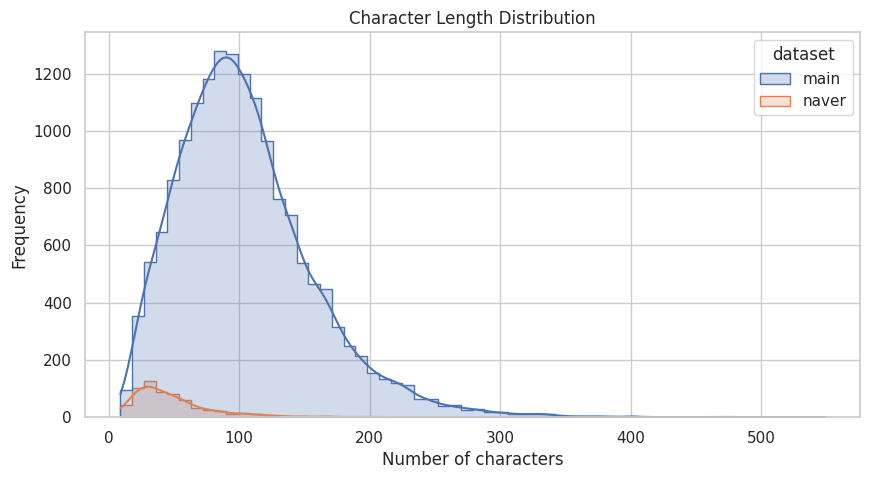

,count,mean,std,min,25%,50%,75%,max
dataset,,,,,,,,
main,16127.0,104.527562,53.030397,9.0,68.0,97.0,132.0,549.0
naver,642.0,48.288162,30.872232,9.0,27.0,40.0,59.0,200.0


In [29]:
# Text length distribution
texts_main = df_main[['record_id', 'text']].drop_duplicates().copy()
texts_naver = df_naver[['record_id', 'text']].drop_duplicates().copy()

texts_main['char_len'] = texts_main['text'].str.len()
texts_naver['char_len'] = texts_naver['text'].str.len()

len_df = pd.concat([
    pd.DataFrame({'dataset': 'main', 'char_len': texts_main['char_len']}),
    pd.DataFrame({'dataset': 'naver', 'char_len': texts_naver['char_len']})
], ignore_index=True)

plt.figure(figsize=(10, 5))
sns.histplot(data=len_df, x='char_len', hue='dataset', bins=60, kde=True, element='step')
plt.title('Character Length Distribution')
plt.xlabel('Number of characters')
plt.ylabel('Frequency')
plt.show()

len_df.groupby('dataset')['char_len'].describe()

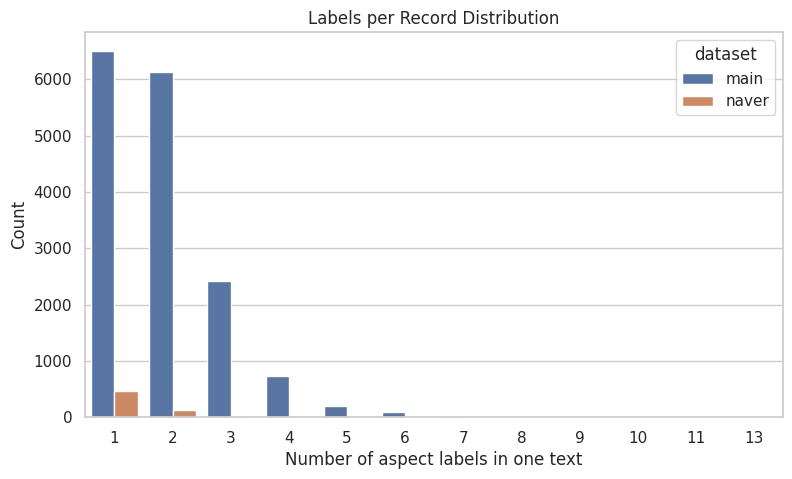

,count,mean,std,min,25%,50%,75%,max
dataset,,,,,,,,
main,16127.0,1.910647,1.010126,1.0,1.0,2.0,2.0,13.0
naver,642.0,1.372274,0.751521,1.0,1.0,1.0,2.0,7.0


In [30]:
# Number of labeled aspects per record
labels_main = df_main[df_main['aspect'].notna()].groupby('record_id').size().rename('labels_per_record')
labels_naver = df_naver[df_naver['aspect'].notna()].groupby('record_id').size().rename('labels_per_record')

labels_df = pd.concat([
    pd.DataFrame({'dataset': 'main', 'labels_per_record': labels_main.values}),
    pd.DataFrame({'dataset': 'naver', 'labels_per_record': labels_naver.values})
], ignore_index=True)

plt.figure(figsize=(9, 5))
sns.countplot(data=labels_df, x='labels_per_record', hue='dataset')
plt.title('Labels per Record Distribution')
plt.xlabel('Number of aspect labels in one text')
plt.ylabel('Count')
plt.show()

labels_df.groupby('dataset')['labels_per_record'].describe()

In [31]:
# Aspect-polarity cross tab for each dataset
def aspect_polarity_table(df: pd.DataFrame, top_n_aspects: int = 12) -> pd.DataFrame:
    tmp = df[df['aspect'].notna() & df['polarity'].notna()].copy()
    top_aspect_list = tmp['aspect'].value_counts().head(top_n_aspects).index.tolist()
    filtered = tmp[tmp['aspect'].isin(top_aspect_list)]
    return pd.crosstab(filtered['aspect'], filtered['polarity'])

main_cross = aspect_polarity_table(df_main, top_n_aspects=12)
naver_cross = aspect_polarity_table(df_naver, top_n_aspects=12)

display(main_cross)
display(naver_cross)

polarity,negative,neutral,positive
aspect,,,
bar,31,330,35
dinner,16,365,33
drinks,26,202,67
food,268,264,801
menu,56,391,124
place,130,22,216
player,94,0,166
price,71,50,195
service,403,47,447


polarity,negative,neutral,positive
aspect,,,
Food,0,1,4
atmosphere,0,0,7
beer,1,0,4
burgers,1,0,4
chicken,1,0,4
coffee,1,0,15
food,7,2,48
menu,2,1,4
place,1,1,31


In [32]:
# Optional: export summary tables
out_dir = '/kaggle/working/eda_outputs' if os.path.exists('/kaggle') else 'eda_outputs'
os.makedirs(out_dir, exist_ok=True)

summary_table.to_csv(os.path.join(out_dir, 'dataset_summary.csv'), index=False)
sentiment_counts.to_csv(os.path.join(out_dir, 'sentiment_distribution.csv'), index=False)
top_main.to_csv(os.path.join(out_dir, 'top_aspects_main.csv'), index=False)
top_naver.to_csv(os.path.join(out_dir, 'top_aspects_naver.csv'), index=False)

print('Saved EDA tables to:', out_dir)

Saved EDA tables to: eda_outputs
